In [2]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

In [3]:
folder = "/work/bd0620/b309199/linear-mws"
flavors = ["pmap_mpdata", "pmap_nx2048", "pmap_ny65", "pmap_nz1281", "pmap_amp100", "pmap_circle", "pmap_bcy1"]
# flavors = ["pmap_mpdata", "pmap_nx2048", "pmap_ny65", "pmap_nz1281", "pmap_amp100"]

flavor_labels = ["Reference", r"$\frac{1}{2} \, \Delta x$", r"$\frac{1}{2} \, \Delta y$", r"$\frac{1}{2} \, \Delta z$", r"10$\,$h$_m \,=\, 100\,$m", r"Circle"]

all_ds_lists = {}
all_cfgs = {}
for flavor in flavors:

    if flavor == "pmap_bcy1":
        sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", 
                f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
                f"{flavor}_MW_125km", f"{flavor}_MW_150km"]
        # sims = [f"{flavor}_MW_005km", f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km"]
    elif flavor == "pmap_nz1281":
        sims = [f"{flavor}_MW_001km", f"{flavor}_MW_100km"]
    elif flavor == "pmap_nx2048":
        sims = [f"{flavor}_MW_010km"]
    elif flavor == "pmap_ny65":
        sims = [f"{flavor}_MW_100km"]
    elif flavor == "pmap_amp100":
        sims = [f"{flavor}_MW_050km", f"{flavor}_MW_075km"]
    elif flavor == "pmap_circle":
        sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", 
                f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
                f"{flavor}_MW_125km", f"{flavor}_MW_150km"]
    if flavor == "pmap_mpdata":
        sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", 
                f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
                f"{flavor}_MW_125km", f"{flavor}_MW_150km"]
        # sims = [f"{flavor}_MW_001km", f"{flavor}_MW_010km", f"{flavor}_MW_050km", f"{flavor}_MW_100km"]

    ds_list = []
    cfgs = []
    model = flavor.split("_")[0]
    # tstamp = 299
    tstamp = -1
    for sim in sims:
        fpath = os.path.join(folder, sim)
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=tstamp, slices={"x": 0, "y": 0, "z": [0]})
        cfgs.append(cfg)
        ds_list.append(ds)
    all_ds_lists[flavor] = ds_list
    all_cfgs[flavor] = cfgs

stb00: 1.0200000360782724e-05
N: 0.010001141698024647
U: 10.0
rho00: 1.0
AMP: 10.0
f: 0.0001000012192610125
Drag_0: 10.001141698024647
Theoretical maximum: 0.7853981633974483 (pi/4)
Actual max of curve: 0.770108753149593, correction factor: 1.0198535728691884, correction factor_manual: 1.025, a: 62999.23187492757
L: 500.0, Drag: 0.1458029223431905, Drag_vertMom: 0.14513348363997097, Drag_compressible: -7.596960677204692e-09
L: 1000.0, Drag: 0.36988603480239207, Drag_vertMom: 0.36839642253775606, Drag_compressible: -3.614374893698496e-08
L: 2000.0, Drag: 0.6174358684765519, Drag_vertMom: 0.6177912623190317, Drag_compressible: -1.5266465382209715e-07
L: 3000.0, Drag: 0.7077812838150918, Drag_vertMom: 0.7115059104550868, Drag_compressible: -3.580288564125978e-07
L: 5000.0, Drag: 0.7428609541605794, Drag_vertMom: 0.7599169979032665, Drag_compressible: -9.903032015242051e-07
L: 10000.0, Drag: 0.7523456882459288, Drag_vertMom: 0.8037972191251439, Drag_compressible: -3.5472712559149734e-06
L:

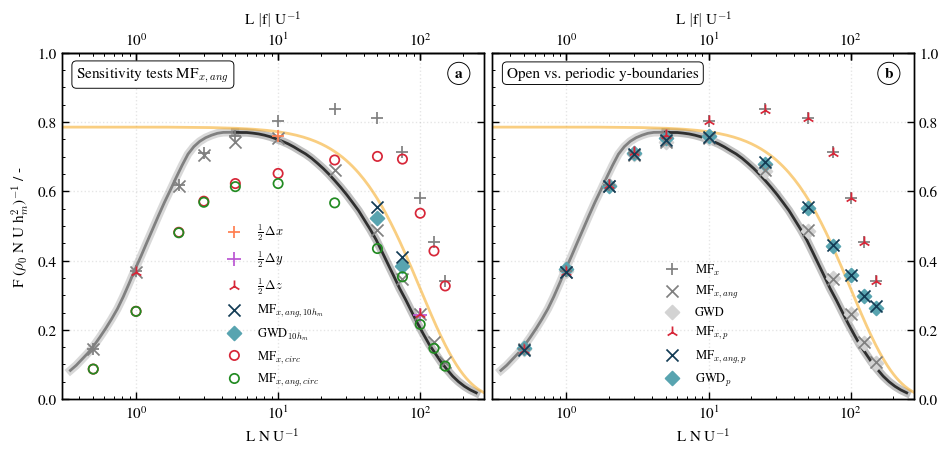

In [7]:
gskw  = {'hspace':0.02, 'wspace':0.02, 'width_ratios': [1,1]}
fig, axes = plt.subplots(1,2, sharex=True, sharey=True, figsize=(11,4.5), gridspec_kw=gskw)
ax0 = axes[0]
ax1 = axes[1]
# axes[-1].axis('off')

color_palette = [
        "#D72638",  # Crimson Red - Primary
        "#F46036",  # Coral Orange - Accent
        "#F6AE2D",  # Golden Sand - Highlight
        "mediumorchid",  # Teal Green - Complementary
        "#2F2F2F",  # Charcoal Gray - Neutral Base
        "grey",  # Mist White - Light Neutral
        "#58A4B0",  # Sky Blue - Cool Accent
        "#133C55"   # Midnight Blue - Deep Shade
    ]
    
c_blumen = color_palette[5]
c_smith = color_palette[4]
c_miranda = color_palette[2]
c1 = color_palette[-1]
c2 = color_palette[-2] # 'mediumorchid'
c3 = color_palette[0]
lw_cross = 1.25
lwall = 2
lw_thick = 6

# flavor_colors = ["#3eabea", "#e53b4f", "#9e1583", "#cf8a0b"]
flavor_colors = [
        "#2F2F2F", # dark grey
        "#D72638",  # Crimson Red - Primary
        "mediumorchid",  # Teal Green - Complementary
        "#F46036",  # Coral Orange - Accent
        "#58A4B0",  # Sky Blue - Cool Accent
        "mediumorchid",  # Teal Green - Complementary
        "#F6AE2D",  # Golden Sand - Highlight
    ]

marks = ["D", "x", "+", "2"]

U = cfg['ambient_fields']['velocity_x']
grav = cfg['constants']['gravity0']
stb00 = cfg['ambient_fields']['stb00']
N = np.sqrt(stb00*grav)
rho00 = cfg['ambient_fields']['rho00']
AMP = cfg['define_orography']['args']['amplitude']
f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)

print(f"stb00: {stb00}")
print(f"N: {N}")
print(f"U: {U}")
print(f"rho00: {rho00}")
print(f"AMP: {AMP}")
print(f"f: {f}")

# N=0.01
# U=10
# f=10**(-4)
drag0 = rho00*U*N*AMP**2
print(f'Drag_0: {drag0}')

# - Linear theory: Bessel functions - #
linear_drag_array = np.loadtxt("../input/drag_gill_page279.txt",usecols=(0, 1), skiprows=0)
nsplit = 28
bessel_drag_max = np.max(linear_drag_array[:,1])
theoretical_max = np.pi/4   # 0.784
factor_corr = theoretical_max / bessel_drag_max
# factor_corr_manual = 1.0
factor_corr_manual = 1.013 # to Smith 1.0198
factor_corr_manual_y = 1
linear_drag_array = factor_corr_manual_y * linear_drag_array
factor_corr_manual = 1.025 # to Smith 1.0198
factor_corr_manual_x = 1
linear_drag_array[:,0] = factor_corr_manual_x * linear_drag_array[:,0]

# - Linear theory: Smith - #
a = 0.63*U/f
smith_x = a * N / U
smith = 0.5 * theoretical_max # drag dropped to half for af/U = 0.63 -> a = 63km
print(f'Theoretical maximum: {theoretical_max} (pi/4)')
print(f'Actual max of curve: {bessel_drag_max}, correction factor: {factor_corr}, correction factor_manual: {factor_corr_manual}, a: {a}')
# ax0.scatter(smith_x, smith, marker='o', s=20, color=c_smith, alpha=0.6, lw=lw_cross) # label='expl. specified (Smith 1979)'
# smith_x = 100000 * N / U
# smith = 0.28*np.pi/4 # af/U = 1 -> a = 100km
# ax0.scatter(smith_x, smith, marker='o', s=50, color='darkorchid', alpha=0.6, lw=lw_cross)
#
smith_x = 30000 * N / U
# smith = 0.8*np.pi/4 # af/U = 1 -> a = 100km
# ax0.scatter(smith_x, smith, marker='o', s=50, color='darkorchid', alpha=0.6, lw=lw_cross)

# ax0.annotate(tstr, (x_regime+, drag_angMom), color='y', transform=ax0.transAxes) # (Smith79)
        
# - Linear Theory: Miranda and James for large L - #
# XML = np.logspace(1,10,100)
XML = np.linspace(1,500000,300)
# print(XML)
XVALUES = XML * N / U
mirandaJames = np.pi/4 * (1+2*f*XML/U)*np.exp(-2*f*XML/U)
mirandaJames2 = np.pi/4 * XML * (1+2*f*XML/U)*np.exp(-2*f*XML/U)
# ax0.plot(XVALUES,mirandaJames*XML, color='darkgoldenrod', alpha=0.6, lw=2, ls='--', label=r"Miranda and James 1992")

ax0.plot(linear_drag_array[:nsplit+1,0],linear_drag_array[:nsplit+1,1], color=c_blumen, lw=lw_thick, alpha=0.3)
ax0.plot(linear_drag_array[nsplit:,0],linear_drag_array[nsplit:,1], color=c_smith, lw=lw_thick, alpha=0.3)
ax0.plot(linear_drag_array[:nsplit+1,0],linear_drag_array[:nsplit+1,1], color=c_blumen, lw=lwall)
ax0.plot(linear_drag_array[nsplit:,0],linear_drag_array[nsplit:,1], color=c_smith, lw=lwall)
ax0.plot(XVALUES,mirandaJames, color=c_miranda, alpha=0.6, lw=lwall, ls='-')
ax1.plot(linear_drag_array[:nsplit+1,0],linear_drag_array[:nsplit+1,1], color=c_blumen, lw=lw_thick, alpha=0.3)
ax1.plot(linear_drag_array[nsplit:,0],linear_drag_array[nsplit:,1], color=c_smith, lw=lw_thick, alpha=0.3)
ax1.plot(linear_drag_array[:nsplit+1,0],linear_drag_array[:nsplit+1,1], color=c_blumen, lw=lwall)
ax1.plot(linear_drag_array[nsplit:,0],linear_drag_array[nsplit:,1], color=c_smith, lw=lwall)
ax1.plot(XVALUES,mirandaJames, color=c_miranda, alpha=0.6, lw=lwall, ls='-')

## Diff axis
ax0d = ax0.twinx()
ax1d = ax1.twinx()

abs_factor = 1
z = 0
j = 0

for flavor, ds_list in all_ds_lists.items(): 

    col = flavor_colors[j]
    
    cfgs = all_cfgs[flavor]
    model = flavor.split("_")[0]
    for i, ds in enumerate(ds_list):
        cfg = cfgs[i]
        L = cfg['define_orography']['args']['halfwidth']
        AMP = cfg['define_orography']['args']['amplitude']
        x_regime = L * N / U
    
        if cfg['absorber']['xboundaries']:
            nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
            nrelax1 = cfg['nx'] - nrelax0
        else:
            nrelax0 = 0
            nrelax1 = cfg['nx']
        
        zs = ds['zcr'][0,:].values
        dzdx_surf = np.gradient(zs, cfg['dx'], axis=0)
        pprime = ds['pprime']
        uprime = ds['u'] - U
        vprime = ds['v']
        wprime = ds['w']
        rhoprime = ds['rhoprime']
        # rho = ds['density']
        # rho0 = ds['rho0']
        # th = ds['theta_total']
        # thprime = ds['thprime']
        xcr = ds.x[nrelax0:nrelax1]
        
        # - Drag from pressure perturbation - #
        drag = integrate.trapezoid(pprime[z,nrelax0:nrelax1] * dzdx_surf[nrelax0:nrelax1], xcr) # 0.3576
        # drag = integrate.simps(ds.pprime[12,z,y,:] * ds.dzdx_surf[y,:], 1000*ds.xcr[y,:])
    
        # - Drag from vertical flux of angular momentum (vertical momentum flux + streamwise Coriolis force) - # 
        drag_vertMom = -rho00* integrate.trapezoid(uprime[z,nrelax0:nrelax1] * wprime[z,nrelax0:nrelax1], xcr)
        drag_f = -f * rho00 * integrate.trapezoid(vprime[z,nrelax0:nrelax1] * zs[nrelax0:nrelax1], xcr)
        # drag_vertMom_v = -ds['rh0'][0,z,0,0]*integrate.trapezoid((ds.v[z,y,n_sponge:ds.nx-n_sponge]-ds.ve[z,y,n_sponge:ds.nx-n_sponge])*ds.w[z,y,n_sponge:ds.nx-n_sponge], 1000.*ds.xcr[y,n_sponge:ds.nx-n_sponge])
        
        # - Drag from compressible effects (rho') - #
        # thloc = ds['the'][z,y,n_sponge:ds.nx-n_sponge] + ds['th'][z,y,n_sponge:ds.nx-n_sponge] # Theta
        # tloc = thloc*(ds['pr0'][z,y,n_sponge:ds.nx-n_sponge]/ds['pref00'])**ds.cap # T
        # tte = ds['the'][z,:,:]*(ds['pr0'][z,:,:]/ds['pref00'])**ds.cap # T_env
        # ploc = ds['pprime'][z,y,n_sponge:ds.nx-n_sponge]+ds['pr0'][z,y,n_sponge:ds.nx-n_sponge]
        # rholoc = ploc/(ds.rg*tloc)
    
        drag_comp = -f * integrate.trapezoid(rhoprime[z,nrelax0:nrelax1] * vprime[z,nrelax0:nrelax1] * zs[nrelax0:nrelax1], xcr)
            
        # - Normalized drag - #
        drag0 = rho00*U*N*AMP**2
        drag         = drag         / drag0
        drag_vertMom = drag_vertMom / drag0
        drag_f       = drag_f       / drag0
        drag_comp    = drag_comp    / drag0
    
        drag_angMom  = drag_vertMom + drag_f
        # drag_angMom  = drag_vertMom + drag_f + drag_comp # drag_vertMom_v
        print(f"L: {L}, Drag: {drag}, Drag_vertMom: {drag_vertMom}, Drag_compressible: {drag_comp}")
    
        a1 = 1
        ss  = 75
        ss2 = 50
            
        if flavor == "pmap_bcy1":
            if i == 0:
                ax1.scatter(x_regime, drag_vertMom, marker="2", s=ss, color=c3, alpha=a1, lw=lw_cross, zorder=10, label=r'MF$_{x,p}$')
                ax1.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10, label=r'MF$_{x,ang,p}$')
                ax1.scatter(x_regime, drag, marker=marks[0], s=ss2, color=c2, alpha=a1, lw=lw_cross, zorder=9, label=r'GWD$_p$')
            else:
                ax1.scatter(x_regime, drag_vertMom, marker="2", s=ss, color=c3, alpha=a1, lw=lw_cross, zorder=10)
                ax1.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10)
                ax1.scatter(x_regime, drag, marker=marks[0], s=ss2, color=c2, alpha=a1, lw=lw_cross, zorder=9)
        elif flavor == "pmap_amp100":
            if i==0:
                ax0.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10, label=r"MF$_{x,ang,10h_m}$")
                ax0.scatter(x_regime, drag, marker=marks[0], s=ss2, color=col, alpha=a1, lw=lw_cross, zorder=9, label=r"GWD$_{10h_m}$")
            else:
                ax0.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10)
                ax0.scatter(x_regime, drag, marker=marks[0], s=ss2, color=col, alpha=a1, lw=lw_cross, zorder=9)
        elif flavor == "pmap_circle":
            if i == 0:
                ax0.scatter(x_regime, drag_vertMom, marker='o', facecolor='none', s=ss-30, edgecolor="#D72638", alpha=a1, lw=lw_cross, zorder=10, label=r"MF$_{x,circ}$")
                ax0.scatter(x_regime, drag_angMom, marker='o', facecolor='none', s=ss-30, edgecolor='forestgreen', alpha=a1, lw=lw_cross, zorder=10, label=r"MF$_{x,ang,circ}$")
            else:
                ax0.scatter(x_regime, drag_vertMom, marker='o', facecolor='none', s=ss-30, edgecolor="#D72638", alpha=a1, lw=lw_cross, zorder=10)
                ax0.scatter(x_regime, drag_angMom, marker='o', facecolor='none', s=ss-30, edgecolor='forestgreen', alpha=a1, lw=lw_cross, zorder=10)
        elif flavor == "pmap_mpdata":
            if i == 0:
                ax0.scatter(x_regime, drag_vertMom, marker=marks[2], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=9)
                ax0.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=9)
            else:
                ax0.scatter(x_regime, drag_vertMom, marker=marks[2], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=9)
                ax0.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=9)
            if i == 0: 
                ax1.scatter(x_regime, drag_vertMom, marker=marks[2], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=10, label=r'MF$_x$')
                ax1.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=10, label=r'MF$_{x,ang}$')
                ax1.scatter(x_regime, drag, marker=marks[0], s=ss2, color='lightgrey', alpha=a1, lw=lw_cross, zorder=9, label=r'GWD')
            else:
                ax1.scatter(x_regime, drag_vertMom, marker=marks[2], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=10)
                ax1.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=10)
                ax1.scatter(x_regime, drag, marker=marks[0], s=ss2, color='lightgrey', alpha=a1, lw=lw_cross, zorder=9)
        elif flavor=="pmap_nx2048":
            ax0.scatter(x_regime, drag_angMom, marker=marks[2], s=ss, color='coral', alpha=a1, lw=lw_cross, zorder=10, label=flavor_labels[j])
        elif flavor=="pmap_ny65":
            ax0.scatter(x_regime, drag_angMom, marker=marks[2], s=ss+20, color=col, alpha=a1, lw=lw_cross, zorder=10, label=flavor_labels[j])
        elif flavor=="pmap_nz1281":
            if i == 0:
                ax0.scatter(x_regime, drag_angMom, marker="2", s=ss, color="#D72638", alpha=a1, lw=lw_cross, zorder=10, label=flavor_labels[j])
            else:
                ax0.scatter(x_regime, drag_angMom, marker="2", s=ss, color="#D72638", alpha=a1, lw=lw_cross, zorder=10)
        else:
            if i == 0:
                ax0.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=col, alpha=a1, lw=lw_cross, zorder=10, label=flavor_labels[j])
            else:
                ax0.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=col, alpha=a1, lw=lw_cross, zorder=10)

    # if j > 0:
    #     ax0d.plot(xregimes, diff_drag)
    #     ax1d.plot(xregimes, diff_amom)
    j += 1
    

# - Formatting and saving - #
xtick_labels_top = ['xx','xx','0.01','0.1','1','xx']

numstr = ['a','b']
ax_labels = [r"Sensitivity tests MF$_{x,ang}$", r"Open vs. periodic y-boundaries"]

for i, ax in enumerate(axes.flatten()):
    if i < 2:
        ax.text(0.035, 0.93, ax_labels[i], transform=ax.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax.text(0.95, 0.93, numstr[i], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax.grid()
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        ax_t = ax.secondary_xaxis('top')
        xticks = ax_t.get_xticks()
        ax_t.set_xticks(xticks)
        ax_t.set_xticklabels(xtick_labels_top)
        ax_t.set_xlabel(r"L $|$f$|$ U$^{-1}$")

ax0.set_ylim([0,1])
ax0.set_xlim([3*10**(-1),2.8*10**(2)])
ax0.xaxis.set_minor_locator(AutoMinorLocator(5))
ax0.yaxis.set_minor_locator(AutoMinorLocator())
ax0.set_xscale('log')
# ax0.legend(loc='upper left')
ax0.legend(loc='lower center', frameon=False, fontsize=9)
ax1.legend(loc='lower center', frameon=False, fontsize=9) # , ncols=2)
# ax0.set_ylabel(r'F ($\rho_0$ N U h$_m^2$)$^{-1}$ / -')
ax0.set_ylabel(r'F ($\rho_0$ N U h$_m^2$)$^{-1}$ / -')
ax0.set_xlabel(r'L N U$^{-1}$')
ax1.set_xlabel(r'L N U$^{-1}$')
ax0d.tick_params(which='both', labelright=False)

# ax0.xaxis.set_minor_locator(AutoMinorLocator())
# ax1.tick_params(which='both', labelright=True)
# ax_t.xaxis.set_minor_locator(AutoMinorLocator())

# fig.tight_layout()
fig_title = f"surface_gwd_bcy1.png"
fig.savefig('../data/pmap/' + fig_title, facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 50km with circle and bcy1

In [ ]:
"""Notes"""
cfg['ambient_fields']['velocity_x']
cfg['define_orography']['args']
cfg['constants']['fcoriolis0']
cfg['constants']['angle0']